Saurabh Kaushik

# Assignment 3: Credit Card Fraud Detection
### Summer of Quant 2026 — Quant Club, IIT Kharagpur

---

## The Problem

Fraud detection is one of the oldest and most commercially critical applications of machine learning. Visa and Mastercard process over **700 million transactions per day**. Even a fraud rate of 0.1% translates to hundreds of thousands of fraudulent transactions — each carrying real financial loss.

This is an extreme **class imbalance** problem. In a typical credit card dataset, fewer than 0.2% of transactions are fraudulent. A naive model that predicts *'legitimate'* for every transaction achieves 99.8% accuracy — and is completely useless.

This forces us to rethink how we measure model quality. **Accuracy is not the right metric here.** Instead, we care about:

- **Recall (Sensitivity)**: Of all actual frauds, how many did we catch? Missing a fraud is costly.
- **Precision**: Of all flagged transactions, how many were actually fraud? False alarms annoy customers and erode trust.
- **F1-Score**: The harmonic mean of Precision and Recall — our primary optimisation target.
- **AUC-ROC**: How well the model separates the two classes across all decision thresholds.

---

## The Dataset

We use the [Kaggle Credit Card Fraud dataset](https://www.kaggle.com/mlg-ulb/creditcardfraud#creditcard.csv) — a standard benchmark in the field. It contains **284,807 transactions** made by European cardholders over two days in September 2013.

The features `V1` through `V28` are the result of a **PCA transformation** applied to the raw transaction data (anonymised for privacy). The only non-transformed features are `Time`, `Amount`, and `Class` (0 = legitimate, 1 = fraud).

---

## Structure of This Notebook

| Section | Description |
|---|---|
| **1. Setup** | Imports |
| **2. Load & Explore** | Load data, inspect distributions, check class imbalance |
| **3. Preprocessing** | Feature/target split, train-test split, feature scaling |
| **4. Model Building** | Decision Tree, Random Forest, AdaBoost, XGBoost |
| **5. Evaluation** | Confusion matrix, classification report |
| **6. Bonus Challenge** | SMOTE oversampling + Precision-Recall curve + threshold tuning |

---

## 1. Importing Necessary Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 110

## 2. Load the Dataset

Download the dataset from Kaggle: <a href='https://www.kaggle.com/mlg-ulb/creditcardfraud#creditcard.csv'>click here</a>

Then load it using [pd.read_csv](https://pandas.pydata.org/docs/reference/api/pandas.read_csv.html) and print the first few rows.

In [2]:
# Load the dataset and print the first few rows
import kagglehub

# Download latest version
path = kagglehub.dataset_download("mlg-ulb/creditcardfraud")

print("Path to dataset files:", path)


Using Colab cache for faster access to the 'creditcardfraud' dataset.
Path to dataset files: /kaggle/input/creditcardfraud


In [3]:
import os
# Find the exact CSV file name in the downloaded path
csv_path = os.path.join(path, 'creditcard.csv')
data = pd.read_csv(csv_path)
data.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


### Explore the Data

**Print the column names, shape, and descriptive statistics.**

In [4]:
# Print column names
print("Columns:", data.columns.tolist())

Columns: ['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount', 'Class']


In [6]:
# Print shape of the data
print("Shape:", data.shape)
# Print descriptive statistics
display(data.describe())

Shape: (284807, 31)


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
count,284807.000000,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,...,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,284807.000000,284807.000000
mean,94813.859575,1.168375e-15,3.416908e-16,-1.379537e-15,2.074095e-15,9.604066e-16,1.487313e-15,-5.556467e-16,1.213481e-16,-2.406331e-15,...,1.654067e-16,-3.568593e-16,2.578648e-16,4.473266e-15,5.340915e-16,1.683437e-15,-3.660091e-16,-1.227390e-16,88.349619,0.001727
std,47488.145955,1.958696e+00,1.651309e+00,1.516255e+00,1.415869e+00,1.380247e+00,1.332271e+00,1.237094e+00,1.194353e+00,1.098632e+00,...,7.345240e-01,7.257016e-01,6.244603e-01,6.056471e-01,5.212781e-01,4.822270e-01,4.036325e-01,3.300833e-01,250.120109,0.041527
min,0.000000,-5.640751e+01,-7.271573e+01,-4.832559e+01,-5.683171e+00,-1.137433e+02,-2.616051e+01,-4.355724e+01,-7.321672e+01,-1.343407e+01,...,-3.483038e+01,-1.093314e+01,-4.480774e+01,-2.836627e+00,-1.029540e+01,-2.604551e+00,-2.256568e+01,-1.543008e+01,0.000000,0.000000
25%,54201.500000,-9.203734e-01,-5.985499e-01,-8.903648e-01,-8.486401e-01,-6.915971e-01,-7.682956e-01,-5.540759e-01,-2.086297e-01,-6.430976e-01,...,-2.283949e-01,-5.423504e-01,-1.618463e-01,-3.545861e-01,-3.171451e-01,-3.269839e-01,-7.083953e-02,-5.295979e-02,5.600000,0.000000
50%,84692.000000,1.810880e-02,6.548556e-02,1.798463e-01,-1.984653e-02,-5.433583e-02,-2.741871e-01,4.010308e-02,2.235804e-02,-5.142873e-02,...,-2.945017e-02,6.781943e-03,-1.119293e-02,4.097606e-02,1.659350e-02,-5.213911e-02,1.342146e-03,1.124383e-02,22.000000,0.000000
75%,139320.500000,1.315642e+00,8.037239e-01,1.027196e+00,7.433413e-01,6.119264e-01,3.985649e-01,5.704361e-01,3.273459e-01,5.971390e-01,...,1.863772e-01,5.285536e-01,1.476421e-01,4.395266e-01,3.507156e-01,2.409522e-01,9.104512e-02,7.827995e-02,77.165000,0.000000
max,172792.000000,2.454930e+00,2.205773e+01,9.382558e+00,1.687534e+01,3.480167e+01,7.330163e+01,1.205895e+02,2.000721e+01,1.559499e+01,...,2.720284e+01,1.050309e+01,2.252841e+01,4.584549e+00,7.519589e+00,3.517346e+00,3.161220e+01,3.384781e+01,25691.160000,1.000000


**Check for null values and drop if any.**

Use `data = data.dropna()` if nulls are present.

In [8]:
print("Null values before drop:\n", data.isna().sum())
data = data.dropna()

Null values before drop:
 Time      0
V1        0
V2        0
V3        0
V4        0
V5        0
V6        0
V7        0
V8        0
V9        0
V10       0
V11       0
V12       0
V13       0
V14       0
V15       0
V16       0
V17       0
V18       0
V19       0
V20       0
V21       0
V22       0
V23       0
V24       0
V25       0
V26       0
V27       0
V28       0
Amount    0
Class     0
dtype: int64


## Data Visualisation

**Plot histograms of every feature** using `.hist()`. This gives a quick overview of each feature's distribution.

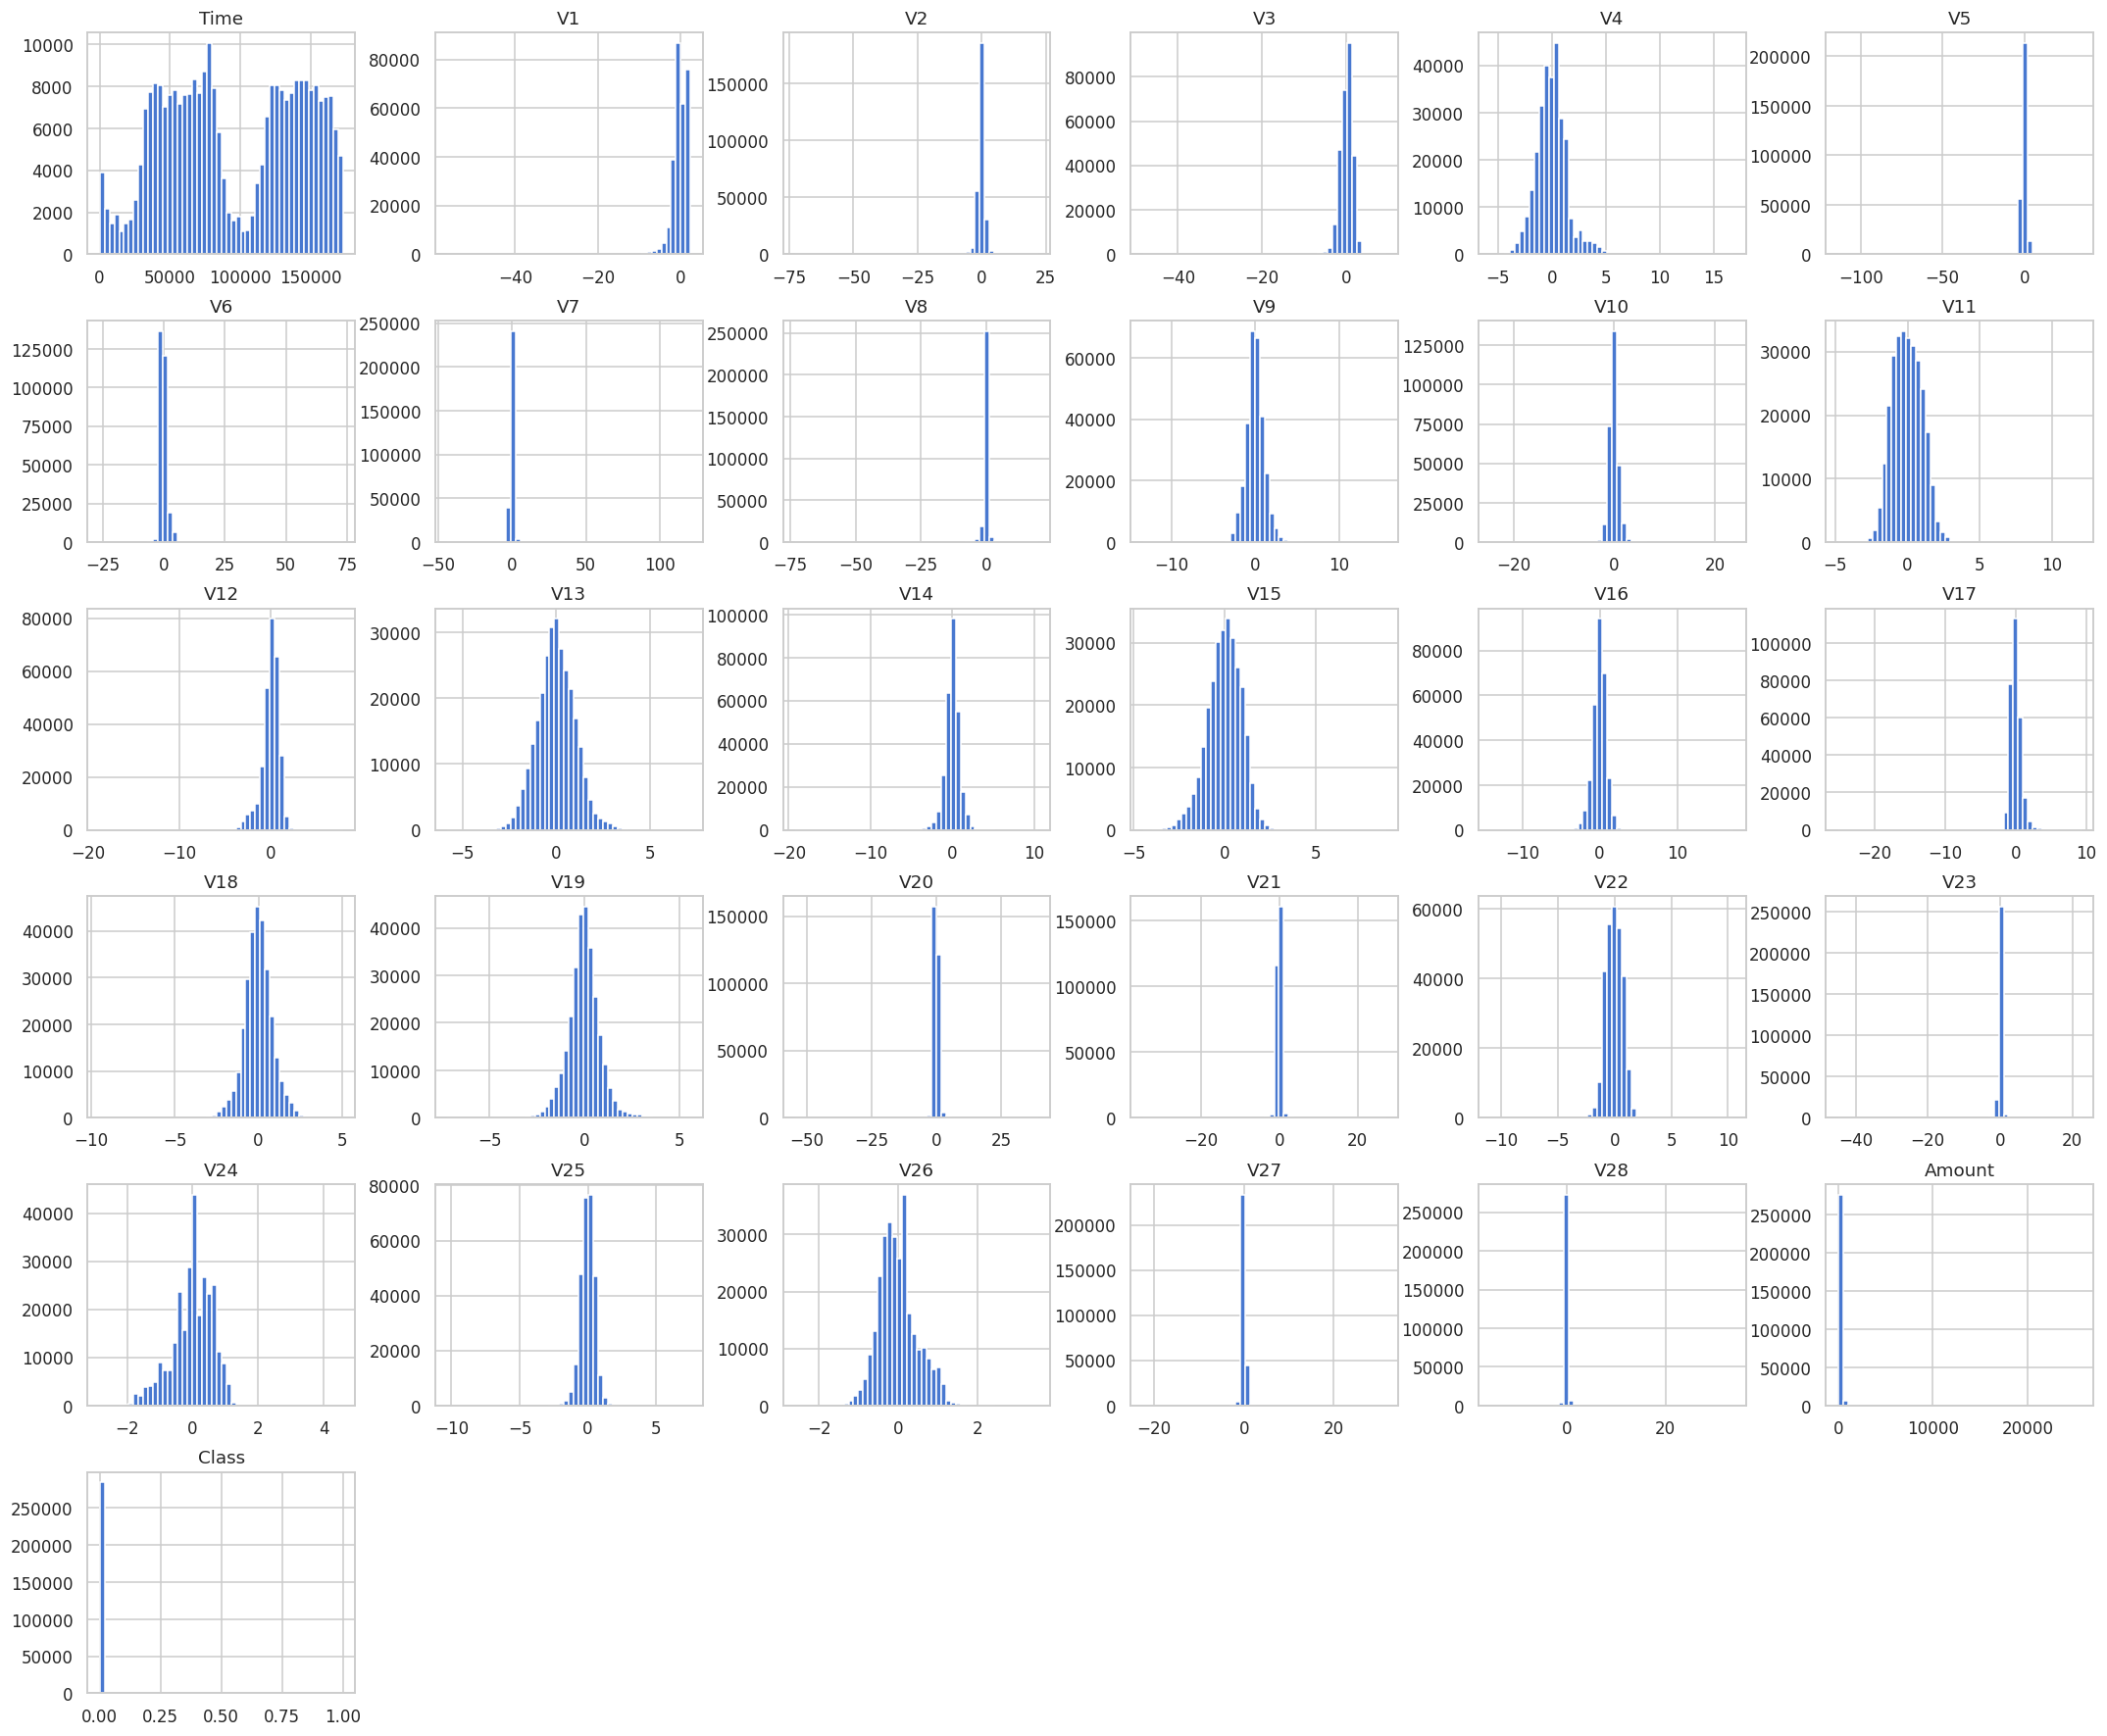

In [10]:
# Plot histograms of each parameter
data.hist(figsize=(24, 20), bins=50)
plt.show()

**Print the count of fraud vs. legitimate transactions using Boolean Indexing.**

In [11]:
# Count fraud (Class == 1) and legitimate (Class == 0) cases
print(data['Class'].value_counts())

Class
0    284315
1       492
Name: count, dtype: int64


**Plot a correlation heatmap using Seaborn.**

Useful references:
1. [pandas.DataFrame.corr](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.corr.html)
2. [seaborn.heatmap](https://seaborn.pydata.org/generated/seaborn.heatmap.html)
3. [matplotlib.pyplot.figure](https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.figure.html)

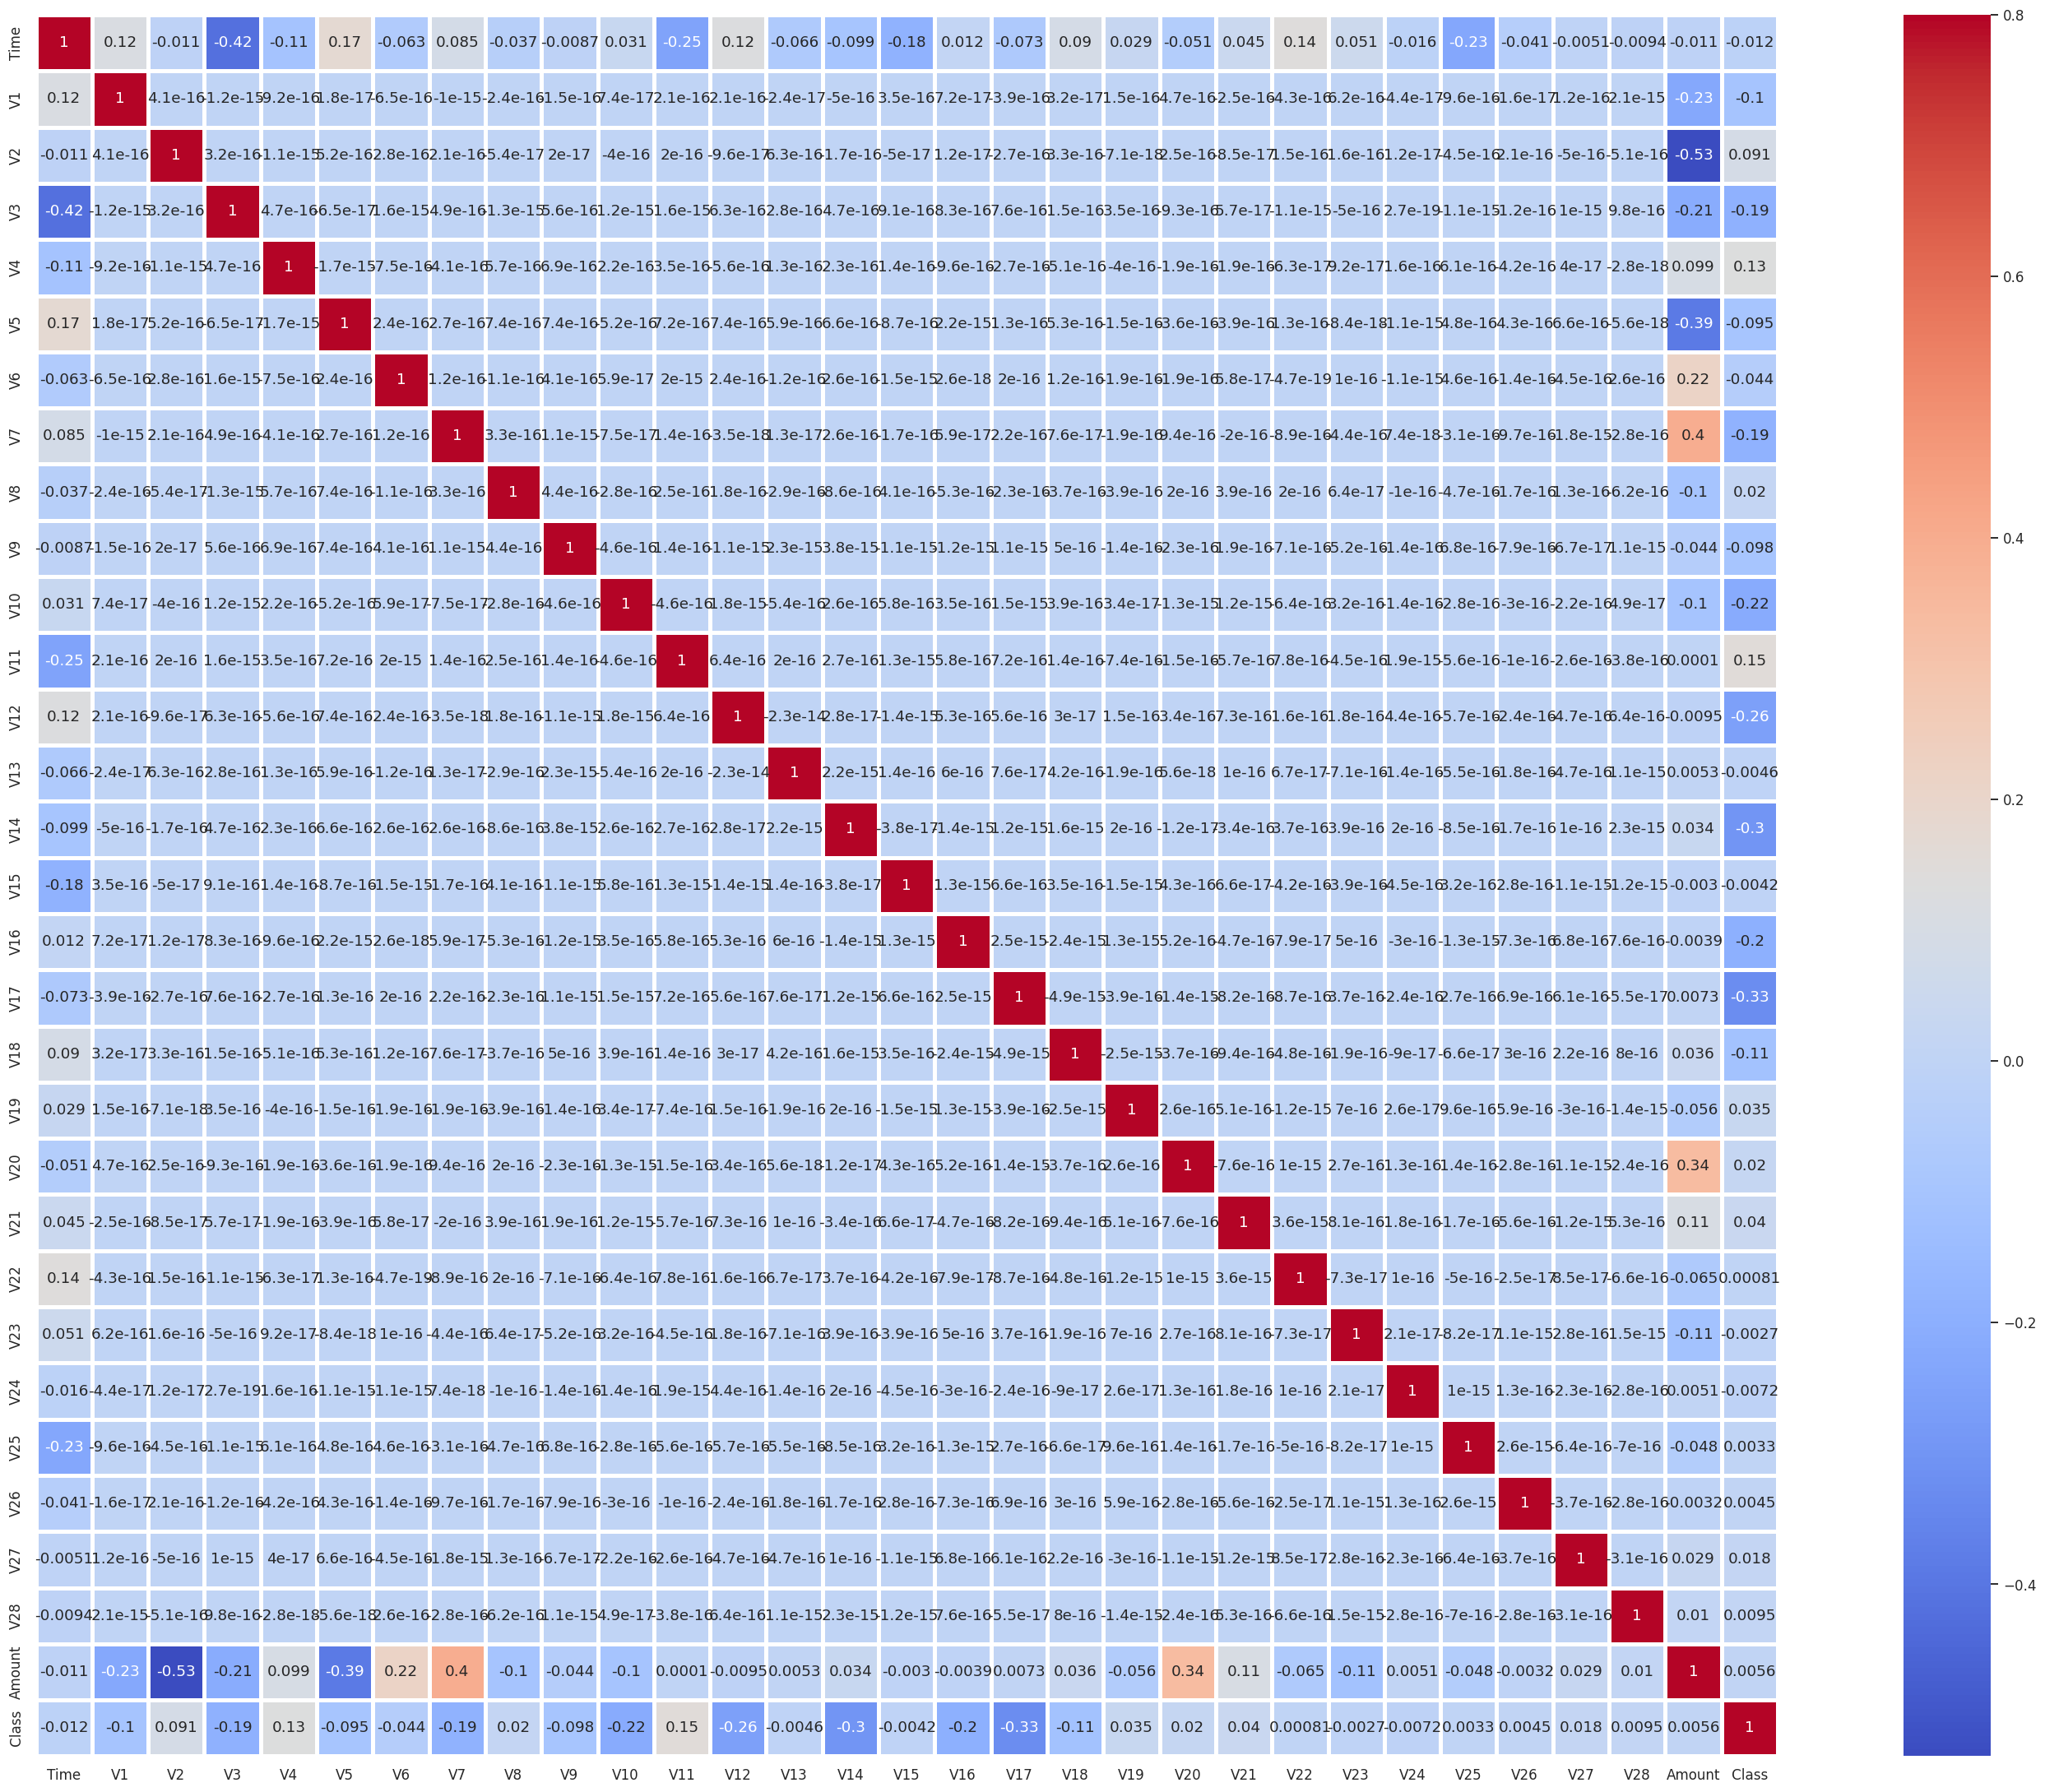

In [12]:
# Correlation heatmap
corrmat = data.corr()
fig = plt.figure(figsize=(36, 25))
sns.heatmap(corrmat, vmax=.8, square=True, annot=True, cmap='coolwarm', linewidth=2)
plt.show()

## 3. Data Preprocessing



### 3.1 Splitting a DataFrame into Features (X) and Target (Y)

In this step, we’ll split the given DataFrame into two parts:

Features (X): These are the columns that we’ll use as input to our machine learning model. They represent the independent variables that help predict the target variable.

Target (Y): This is the column we want to predict. In our case, it’s the “Class” column.

## Instructions:

1. Get All Columns: First, let’s get a list of all the columns in the DataFrame. We’ll use this list to filter out the columns we don’t want.
2. Filter Columns: Remove any columns that are not relevant for our prediction.

In our case, we want to exclude the “Class” column from the features.
Store Variables:
X: Assign the remaining columns (excluding “Class”) to the variable X. These will be our features.
Y: Assign the “Class” column to the variable Y. This will be our target.
Print Shapes: Finally, print the shapes of X and Y to verify that everything is set up correctly.

In [13]:
# Get all column names as a list
columns = data.columns.tolist()

# Remove 'Class' from the list
columns.remove('Class')
target = 'Class'

X = data[columns]    # all features
Y = data[target]     # target label

# Print shapes
print("X shape:", X.shape)
print("Y shape:", Y.shape)

X shape: (284807, 30)
Y shape: (284807,)


### 3.2 Train / Test Split (80% train, 20% test)

[Docs](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.train_test_split.html)

Use `random_state=42` and `stratify=Y` to preserve class proportions in both splits.

In [14]:
from sklearn.model_selection import train_test_split

# Split into 80% train, 20% test
X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size=0.20, random_state=42, stratify=Y)

In [15]:
# Print shapes of X_train, X_test, y_train, y_test
print("X_train:", X_train.shape, "| X_test:", X_test.shape)
print("y_train:", y_train.shape, "| y_test:", y_test.shape)

X_train: (227845, 30) | X_test: (56962, 30)
y_train: (227845,) | y_test: (56962,)


### 3.3 Feature Scaling

Many algorithms (especially distance-based ones) are sensitive to feature magnitude. `StandardScaler` standardises each feature to zero mean and unit variance.

[Docs](https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.StandardScaler.html)

> **Note:** We call `.fit_transform()` on train data and `.transform()` (not `.fit_transform()`) on test data. Fitting on test data would be **data leakage** — the scaler would gain information about the test distribution before evaluation.

In [16]:
from sklearn.preprocessing import StandardScaler

sc = StandardScaler()
X_train_sc = sc.fit_transform(X_train)   # fit on train, transform train
X_test_sc  = sc.transform(X_test)        # transform test using train's parameters
print(X_test_sc.dtype)

float64


## 4. Machine Learning Model Building

Since `Class` is categorical (0 or 1), this is a **supervised binary classification** problem. We will train and compare four classifiers.

In [17]:
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score

### 4.1 Decision Tree Classifier

[Docs — DecisionTreeClassifier](https://scikit-learn.org/stable/modules/generated/sklearn.tree.DecisionTreeClassifier.html)

[Docs — accuracy_score](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.accuracy_score.html)

In [18]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

# Train a Decision Tree on raw (unscaled) data
dt_clf = DecisionTreeClassifier(random_state=42)
dt_clf.fit(X_train, y_train)
print('Decision Tree (raw):', accuracy_score(y_test, dt_clf.predict(X_test)))

Decision Tree (raw): 0.9991397773954567


In [19]:
# Train a Decision Tree on scaled data (X_train_sc / X_test_sc) and print accuracy score
dt_clf_sc = DecisionTreeClassifier(random_state=42)
dt_clf_sc.fit(X_train_sc, y_train)
print('Decision Tree (scaled):', accuracy_score(y_test, dt_clf_sc.predict(X_test_sc)))

Decision Tree (scaled): 0.9991397773954567


### 4.2 Random Forest Classifier

[Docs](https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.RandomForestClassifier.html)

In [20]:
from sklearn.ensemble import RandomForestClassifier

rf_clf = RandomForestClassifier(n_estimators=20, criterion='entropy', random_state=5)
rf_clf.fit(X_train, y_train)
y_pred_rf = rf_clf.predict(X_test)
print('Random Forest (raw):', accuracy_score(y_test, y_pred_rf))

Random Forest (raw): 0.9995962220427653


In [21]:
rf_clf_sc = RandomForestClassifier(n_estimators=20, criterion='entropy', random_state=5)
rf_clf_sc.fit(X_train_sc, y_train)
y_pred_rf_sc = rf_clf_sc.predict(X_test_sc)
print('Random Forest (scaled):', accuracy_score(y_test, y_pred_rf_sc))

Random Forest (scaled): 0.9995962220427653


### 4.3 AdaBoost Classifier

AdaBoost (Adaptive Boosting) trains a sequence of weak learners, each focusing more on the examples that the previous one got wrong. The final prediction is a weighted vote.

[Docs](https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.AdaBoostClassifier.html)

In [22]:
from sklearn.ensemble import AdaBoostClassifier

abd_clf = AdaBoostClassifier(
    DecisionTreeClassifier(criterion='entropy', random_state=20),
    n_estimators=200, learning_rate=0.1, algorithm='SAMME', random_state=1)
abd_clf.fit(X_train, y_train)
y_pred_abd = abd_clf.predict(X_test)
print('AdaBoost (raw):', accuracy_score(y_test, y_pred_abd))

/usr/local/lib/python3.12/dist-packages/sklearn/ensemble/_weight_boosting.py:519: FutureWarning: The parameter 'algorithm' is deprecated in 1.6 and has no effect. It will be removed in version 1.8.
  warnings.warn(


AdaBoost (raw): 0.9992977774656788


In [23]:
abd_clf_sc = AdaBoostClassifier(
    DecisionTreeClassifier(criterion='entropy', random_state=20),
    n_estimators=200, learning_rate=0.1, algorithm='SAMME', random_state=1)
abd_clf_sc.fit(X_train_sc, y_train)
y_pred_abd_sc = abd_clf_sc.predict(X_test_sc)
print('AdaBoost (scaled):', accuracy_score(y_test, y_pred_abd_sc))

/usr/local/lib/python3.12/dist-packages/sklearn/ensemble/_weight_boosting.py:519: FutureWarning: The parameter 'algorithm' is deprecated in 1.6 and has no effect. It will be removed in version 1.8.
  warnings.warn(


AdaBoost (scaled): 0.9992977774656788


### 4.4 XGBoost Classifier

XGBoost (Extreme Gradient Boosting) is a highly optimised gradient boosted tree library. It is the go-to model for structured/tabular data in competitive ML.

[Docs](https://xgboost.readthedocs.io/en/stable/python/python_api.html#xgboost.XGBClassifier)

**Hint**: Import `XGBClassifier` from `xgboost`. Use `eval_metric='logloss'` and `use_label_encoder=False` to suppress warnings.

In [24]:
from xgboost import XGBClassifier

# Train XGBClassifier on raw data
xgb_clf = XGBClassifier(eval_metric='logloss', random_state=42)
xgb_clf.fit(X_train, y_train)
print('XGBoost (raw):', accuracy_score(y_test, xgb_clf.predict(X_test)))

XGBoost (raw): 0.9994908886626171


In [25]:
# Train XGBClassifier on scaled data
xgb_clf_sc = XGBClassifier(eval_metric='logloss', random_state=42)
xgb_clf_sc.fit(X_train_sc, y_train)
y_pred_best = xgb_clf_sc.predict(X_test_sc) # Saving this as our likely best model
print('XGBoost (scaled):', accuracy_score(y_test, y_pred_best))

XGBoost (scaled): 0.9994908886626171


## 5. Evaluation

Evaluate your **best model** (based on the accuracy scores above) using a confusion matrix and classification report.

Replace `y_pred_best` with the predictions from whichever model performed best.

In [27]:
from sklearn.metrics import confusion_matrix, classification_report

# Create confusion matrix for your best model
cm = confusion_matrix(y_test, y_pred_best)

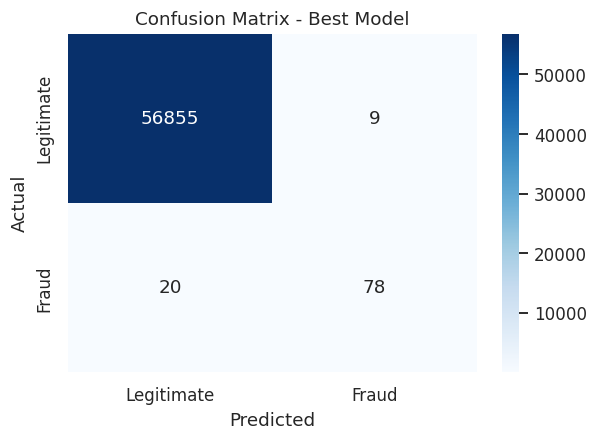

In [28]:
# Plot confusion matrix as a heatmap
# Reference: https://seaborn.pydata.org/generated/seaborn.heatmap.html
# Plot confusion matrix as a heatmap
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Legitimate', 'Fraud'], yticklabels=['Legitimate', 'Fraud'])
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.title('Confusion Matrix - Best Model')
plt.show()


**Print the full classification report.**

[Docs](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.classification_report.html)

In [29]:
# Print classification report
print(classification_report(y_test, y_pred_best))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.90      0.80      0.84        98

    accuracy                           1.00     56962
   macro avg       0.95      0.90      0.92     56962
weighted avg       1.00      1.00      1.00     56962



---

## 6. Bonus Challenge (Optional): Handling Class Imbalance Properly

If you made it here — this is where things get genuinely hard.

Notice the models that achieve very high *accuracy* despite the dataset being heavily imbalanced. High accuracy here is **misleading**. A model that predicts *'legitimate'* for every transaction would score 99.83% accuracy.

The real question is: **how well do our models actually detect fraud?**

### Task 1 — Reframe the Metric

Re-evaluate your best model not by accuracy, but by its **recall on the fraud class** (Class = 1). What fraction of actual frauds did it catch? Print this single number.

> Hint: from the classification report, look at the `recall` row for class `1`.

### Task 2 — SMOTE Oversampling

One standard technique for class imbalance is **SMOTE** (Synthetic Minority Oversampling Technique). Instead of simply duplicating minority class samples, SMOTE generates *synthetic* fraud examples by interpolating between existing ones in feature space.

Install and import: `pip install imbalanced-learn`

[Docs](https://imbalanced-learn.org/stable/references/generated/imblearn.over_sampling.SMOTE.html)

1. Apply SMOTE **only to the training set** (`X_train`, `y_train`). Never resample the test set.
2. Print the class distribution before and after SMOTE.
3. Re-train your best model on the SMOTE-resampled training data.
4. Compare the recall on the fraud class before and after SMOTE. Did it improve?

> **Note:** Applying SMOTE to the test set or the full dataset constitutes data leakage and will give falsely optimistic results.

### Task 3 — Precision-Recall Curve

For fraud detection, the threshold at which we convert predicted probabilities to class labels (default: 0.5) is not necessarily optimal. Lowering it catches more frauds (higher recall) but also flags more legitimate transactions (lower precision).

Use `clf.predict_proba(X_test)[:, 1]` to get fraud probabilities and plot the **Precision-Recall curve**.

[Docs — precision_recall_curve](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.precision_recall_curve.html)

1. Plot Precision vs. Recall for varying thresholds.
2. Mark the point corresponding to the default 0.5 threshold.
3. Compute and print the **Average Precision (AP) score**.

### Task 4 — Threshold Tuning

Pick a threshold that achieves **at least 90% recall on fraud** while keeping precision as high as possible. Print the threshold value you chose and the resulting precision, recall, and F1-score at that threshold.

> **Reflection prompt**: In a real fraud detection system, what are the business consequences of a false negative (missed fraud) vs. a false positive (flagged legitimate transaction)? How would you set the threshold in production, and who in the organisation would make that call?

In [30]:
# --- Task 1: Fraud recall of best model ---
from sklearn.metrics import recall_score
# Focusing specifically on Class 1 (Fraud)
print("Recall on Fraud class (Class=1):", recall_score(y_test, y_pred_best))


Recall on Fraud class (Class=1): 0.7959183673469388


In [32]:
# --- Task 2: SMOTE ---
# !pip install imbalanced-learn
from imblearn.over_sampling import SMOTE

# Apply SMOTE to training data only
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train_sc, y_train)

# Print class distribution before and after
print("Before SMOTE:\n", y_train.value_counts())
print("After SMOTE:\n", y_train_smote.value_counts())

# Re-train best model on resampled data
xgb_smote = XGBClassifier(eval_metric='logloss', random_state=42)
xgb_smote.fit(X_train_smote, y_train_smote)
y_pred_smote = xgb_smote.predict(X_test_sc)

# Compare fraud recall before and after
print("\nRecall BEFORE SMOTE:", recall_score(y_test, y_pred_best))
print("Recall AFTER SMOTE:", recall_score(y_test, y_pred_smote))


Before SMOTE:
 Class
0    227451
1       394
Name: count, dtype: int64
After SMOTE:
 Class
0    227451
1    227451
Name: count, dtype: int64

Recall BEFORE SMOTE: 0.7959183673469388
Recall AFTER SMOTE: 0.8571428571428571


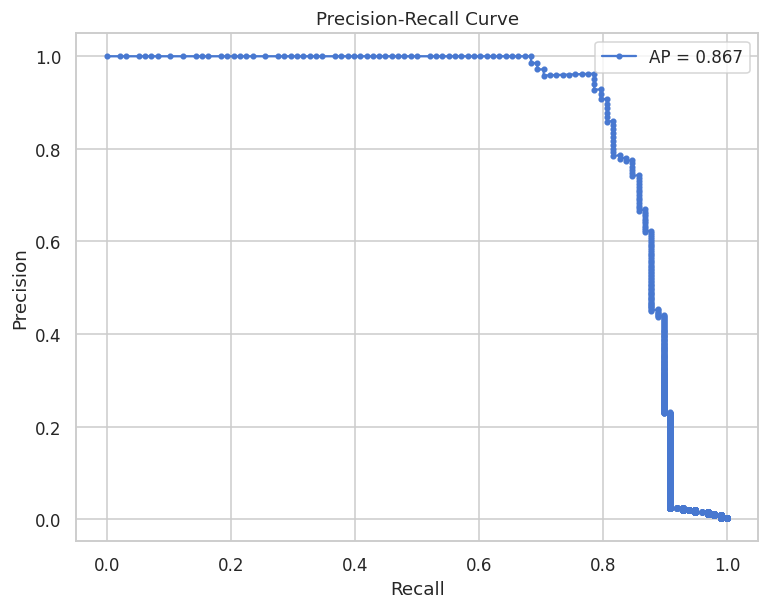

Average Precision Score: 0.8671


In [33]:
# --- Task 3: Precision-Recall Curve ---
from sklearn.metrics import precision_recall_curve, average_precision_score

# Get predicted probabilities for the fraud class (Class 1)
y_probs = xgb_smote.predict_proba(X_test_sc)[:, 1]

# Compute PR curve data
precision, recall, thresholds = precision_recall_curve(y_test, y_probs)
ap_score = average_precision_score(y_test, y_probs)

# Plot Precision-Recall curve
plt.figure(figsize=(8, 6))
plt.plot(recall, precision, marker='.', label=f'AP = {ap_score:.3f}')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.legend()
plt.show()

# Print Average Precision score
print(f"Average Precision Score: {ap_score:.4f}")


In [34]:
# --- Task 4: Threshold Tuning ---
from sklearn.metrics import precision_score, f1_score
import numpy as np

# Find the threshold that achieves >= 90% recall on fraud
# We look for the index where recall is >= 0.90. Since recall arrays go from 1.0 down to 0.0,
# we want the highest threshold that still keeps recall >= 0.9.
valid_indices = np.where(recall >= 0.90)[0]
best_index = valid_indices[-1] # The last index before recall drops below 0.90
chosen_threshold = thresholds[best_index]

# Make predictions based on this new threshold
y_pred_tuned = (y_probs >= chosen_threshold).astype(int)

# Print metrics at that threshold
print(f"Chosen Threshold: {chosen_threshold:.5f}")
print(f"Precision at threshold: {precision_score(y_test, y_pred_tuned):.4f}")
print(f"Recall at threshold: {recall_score(y_test, y_pred_tuned):.4f}")
print(f"F1 at threshold: {f1_score(y_test, y_pred_tuned):.4f}")

Chosen Threshold: 0.02527
Precision at threshold: 0.2306
Recall at threshold: 0.9082
F1 at threshold: 0.3678


**Your reflection:** *(In a real-world scenario, a false negative (missing a fraudulent transaction) results in a direct financial loss to the cardholder and the bank, as well as a loss of customer trust. A false positive (flagging a legitimate transaction as fraud) causes friction and annoyance for the customer (e.g., card declined at dinner) but doesn't immediately lose money. Because the cost of a false negative is mathematically much higher, banks heavily favour higher recall. To implement this in production, I would intentionally lower the decision threshold until we catch an acceptable percentage of fraud (e.g., 90-95%), then use secondary verification (like an automated SMS to the customer asking "Did you make this purchase?") to filter out the false positives. The exact threshold is a business decision typically made jointly by Risk Management and Product teams.)*

---

## Submission Checklist

- [ ] All code cells run top-to-bottom without errors (Kernel -> Restart & Run All).
- [ ] `random_state=42` used consistently throughout.
- [ ] Confusion matrix and classification report are printed for the best model.
- [ ] All plots have axis labels and titles.
- [ ] Bonus Task 4 reflection is filled in.

---

> **Submission:** Submit this notebook with all cells executed (output visible). Include your name at the top.

---

*Summer of Quant 2026 | Quant Club, IIT Kharagpur*